In [1]:
#import netCDF4 as nc
import xarray as xr
import numpy as np
import cartopy
import matplotlib.pyplot as plt
import importlib

import sys
import os

%load_ext autoreload
%autoreload 2
    
# Add the directory containing the package to the search path
sys.path.append(os.path.abspath("/Users/brucel/ecco/yip/ECCO-Insitu-Python"))

# Now you can use standard absolute imports
#import NCEI

# import step01 as update_prof_and_tile_points_on_profiles
# import step02 as update_spatial_bin_index_on_prepared_profiles
# import step03 as update_monthly_mean_TS_clim_WOA13v2_on_prepared_profiles
# import step04 as update_sigmaTS_on_prepared_profiles
# import step05 as update_gamma_factor_on_prepared_profiles
# import step06 as update_prof_insitu_T_to_potential_T
# import step07 as update_zero_weight_points_on_prepared_profiles
# import step08 as update_remove_zero_T_S_weighted_profiles_from_MITprof
# import step09 as update_remove_extraneous_depth_levGels
# import step10 as update_decimate_profiles_subdaily_to_once_daily
import step01
import step02
import step03
import step04
import step05
import step06
import step07
import step08
import step09
import step10
from tools import MITprof_read, MITprof_write_to_nc
import tools

In [2]:
original_file = "/Users/brucel/ecco/yip/scripps_data/CTD_WOD/WOD_WO_1992_CTD_OSD.nc"
#original_file = "/Users/brucel/ecco/yip/scripps_data/GLD_WOD/WOD_WO_2002_GLD.nc"
#original_file = "/Users/brucel/ecco/yip/scripps_data/ITP/L3/ITP_WO_2004_CTD.nc"

In [3]:
#processed_file = "/Users/brucel/ecco/yip/sample_data/test_output_all_files/CTD_WOD/WOD_WO_1992_CTD_OSD__ncei_step_10.nc"

In [4]:
# ==========================================================================================
# ========================== START OF NEED PATHS/ PAREMS ===================================
# ==========================================================================================

# Needed paths:
# Set grid_dir
grid_dir = '/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/grid_llc90'

# Path to dir containing llc090_sphere_point_n_10242_ids.bin and llc090_sphere_point_n_02562_ids.bin
sphere_dir = '/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/grid_llc90/sphere_point_distribution'

# Path to WOA13_v2_TS_clim_merged_with_potential_T.nc
clim_dir = '/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/TS_Climatology'
#clim_dir = '/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/TS_Climatology/WOA13_v2_TS_clim_merged_with_potential_T'

# Path to Salt_sigma_smoothed_method_02_masked_merged_capped_extrapolated.bin and Theta_sigma_smoothed_method_02_masked_merged_capped_extrapolated.bin
CTD_TS_bin = '/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/CTD_sigma_TS'

# Step 1: update_prof_and_tile_points_on_profiles
llcN = 90                       # Which grid to use, 90 or 270
wet_or_all = 1                  # 0 = interpolated to nearest wet point, 1 = interpolated all points, regardless of wet or dry

# Step 4: update_sigmaTS_on_prepared_profiles parems
respect_existing_zero_weights = 0   # 0 = no, 1 = yes
new_S_floor = 0.005                 # set this to zero if S_floor is unused
new_T_floor = 0                     # set this to zero if T_floor is unused

# Step 5: update_gamma_factor_on_prepared_profiles parems
apply_gamma_factor = 1          #   0 = remove gamma factor from sigma, 1 = apply gamma to sigma
                                #   gamma factor is factor 1/sqrt(alpha), where alpha = area/max(area) of the grid cell area in which this profile is found.

# Step 6: update_prof_insitu_T_to_potential_T parems
replace_missing_S_with_clim_S = 1   # 1 = replace, 0 = do not replace

# Step 7: update_zero_weight_points_on_prepared_profiles
# Various parems inside of if block pretaining to 'adjust' on lines 142 - 161 within script

# Step 10: update_decimate_profiles_subdaily_to_once_daily
distance_tolerance = 5e3        # radius within which profiles are considered to be at the same location [in meters]
closest_time = 120000           # HHMMSS: if there is more than one profile per day in a location, choose the one
                                # that is closest in time to 'closest time' default is noon
method = 1                      # method 0 or 1

basename = os.path.basename(original_file)
dest_dir = "/Users/brucel/ecco/yip/ECCO-Insitu-Python/z_test_output"

In [5]:
#MITprofs = NCEI.MITprof_read(original_file,0)

largest_numbered_step_to_run = 10

#MITprofs = MITprof_read(original_file,0)
MITprofs = MITprof_read(original_file,largest_numbered_step_to_run)




In [6]:
prof_vars = list(MITprofs)

In [7]:
# bucket to hold my new, beautiful xarray data arrays 
new_dataarrays = dict()

prof_vars_dims = dict()
# find the number of depth levels
num_k = len(MITprofs['prof_depth'])
# find the number of profiles
num_profs = len(MITprofs['prof_lat'])

# loop through the different variables in the MITprofs structure
for pv in prof_vars:
    #print(MITprofs[pv].shape)
    field_shape = MITprofs[pv].shape 
    ndims = len(field_shape)
    if ndims == 1:
        if field_shape[0] == num_profs:
            #print(f'{pv} is 1D and len={num_profs}')
            new_dataarrays[pv] = xr.DataArray(MITprofs[pv], dims='iPROF', name=pv)
        elif field_shape[0] == num_k:
            #print(f'{pv} is 1D and len={num_k}')
            new_dataarrays[pv] = xr.DataArray(MITprofs[pv], dims='iDEPTH', name=pv)
    elif ndims== 2:
        #print(f'{pv} is 2D and shape is {field_shape}')
        if field_shape[0] == num_profs and field_shape[1] == num_k:
            new_dataarrays[pv] = xr.DataArray(MITprofs[pv], dims=['iPROF', 'iDEPTH'], name=pv)
        else:
            print('====== fail fail fail fail fail ===  calll help lol')

    else:
        print('====== fail fail fail fail fail ===  calll help lol')
        continue

new_dataarrays
MITprof_ds = xr.merge([new_dataarrays])
#MITprof_ds = xr.merge(new_dataarrays)

# dignity has been restored
#MITprof_ds

In [8]:
#MITprof_ds

In [9]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [10]:
%%capture
#update_prof_and_tile_points_on_profiles.main(MITprof_ds, grid_dir, llcN, wet_or_all)
step01.main(MITprof_ds, grid_dir, llcN, wet_or_all)

In [11]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [12]:
%%capture
#update_spatial_bin_index_on_prepared_profiles.main(sphere_dir, MITprof_ds, grid_dir)
step02.main(sphere_dir, MITprof_ds, grid_dir)

In [13]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [14]:
%%capture
#update_monthly_mean_TS_clim_WOA13v2_on_prepared_profiles.main(clim_dir, MITprof_ds)
step03.main(clim_dir, MITprof_ds)

In [15]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [16]:
%%capture
step04.main(MITprof_ds, grid_dir, CTD_TS_bin, respect_existing_zero_weights, new_S_floor, new_T_floor)

In [17]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [18]:
#MITprof_ds['prof_Tweight']

In [19]:
%%capture
#NoTe:  THIS STEP ERASES ENTIRE ROWS OF PROFILE DATA (IE ALL VALUES FOR ALL TIME AT A GIVEN DEPTH INDEX) IF ANY 
#       DATA AT ANY TIME IS BAD/NEGATIVE.  is this intended?  interspersed nans makes the data hard to assimilate?
step05.main(MITprof_ds, grid_dir, apply_gamma_factor, llcN)

In [20]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [21]:
%%capture
importlib.reload(step06)
step06.main(MITprof_ds, replace_missing_S_with_clim_S)


In [22]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [23]:
%%capture
importlib.reload(tools)
importlib.reload(step07)

step07.main('adjust', MITprof_ds)

In [24]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))
# print(f"Tmax: {np.nanmax(MITprof_ds['prof_T'].data)}")

In [25]:
%%capture
#importlib.reload(step08)
#importlib.reload(tools)

step08.main(MITprof_ds)

In [26]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))

In [27]:
%%capture
#importlib.reload(tools)
#importlib.reload(step08)
#importlib.reload(step09)

step09.main(MITprof_ds)

In [28]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))

In [29]:
%%capture
#importlib.reload(tools)
#importlib.reload(step08)
#importlib.reload(step10)

step10.main(MITprof_ds, distance_tolerance, closest_time, method)

In [30]:
# print('Temperature:')
# print(np.sum(~np.isnan(MITprof_ds['prof_T'].data)))

In [31]:
MITprof_write_to_nc(dest_dir, MITprof_ds, 10, basename)

Writing NETCDF files WOD_WO_1992_CTD_OSD.nc


In [32]:
sys.path.append(os.path.abspath("/Users/brucel/ecco/yip/ECCO-Insitu-Python/geodesic_binning"))
import geodesic_binning_utilities as utils

variables_of_interest = ["T", "S"]
num_geodesic_bins = 10242
profile_file_index = 1
angular_precision = 0.25

geodesic_file_dict = {
    "00642": "/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/geodesic/00642_bin_locations.csv",
    "02562": "/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/geodesic/02562_bin_locations.csv",
    "10242": "/Users/brucel/ecco/yip/sample_data/ecco-insitu/sweet_gdrive/geodesic/10242_bin_locations.csv",
}

profile_file_list = [
    "/Users/brucel/ecco/yip/ECCO-Insitu-Python/z_test_output/ITP_WO_2004_CTD__ncei_step_10.nc",
    "/Users/brucel/ecco/yip/ECCO-Insitu-Python/z_test_output/WOD_WO_1992_CTD_OSD__ncei_step_10.nc",
    "/Users/brucel/ecco/yip/ECCO-Insitu-Python/z_test_output/WOD_WO_2002_GLD__ncei_step_10.nc",
]

geodesic_file = geodesic_file_dict[f"{num_geodesic_bins:05}"]
profile_file = profile_file_list[profile_file_index]

geodesic_bin_data = utils.bin_around_geodesic_vertices(geodesic_file, profile_file, variables_of_interest, angular_precision, num_geodesic_bins)



00; T
00; S


In [33]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import matplotlib.patches as mpatches

# plot_var = "T"
# plot_depth = "00"

# xmin,ymin = 1000, 1000
# xmax,ymax = -1000, -1000

# polygon_list = []
# for index in geodesic_bin_data[plot_var][plot_depth].keys():
#     gbd_polygon = geodesic_bin_data[plot_var][plot_depth][index]["artificial_grid_bounding_polygon_for_geodesic_bin"]
#     if gbd_polygon.size > 0:
#         polygon_list.append(
#             mpatches.Polygon(gbd_polygon, closed=True, facecolor='green', alpha=0.3, edgecolor='black'))
#         if xmin > np.min(gbd_polygon[:,0]):
#             xmin = np.min(gbd_polygon[:,0])

#         if xmax < np.max(gbd_polygon[:,0]):
#             xmax = np.max(gbd_polygon[:,0])

#         if ymin > np.min(gbd_polygon[:,1]):
#             ymin = np.min(gbd_polygon[:,1])

#         if ymax < np.min(gbd_polygon[:,1]):
#             ymax = np.min(gbd_polygon[:,1])

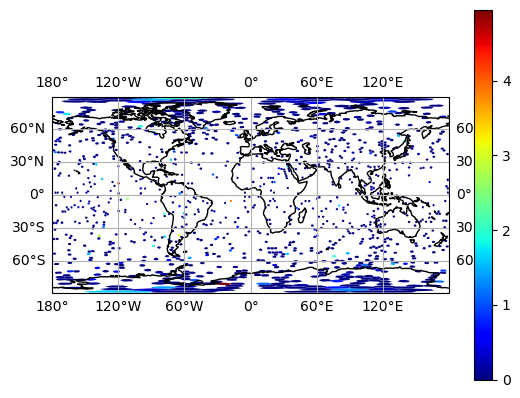

In [34]:
# -------------------------------------------
# If you do this in ipython, you can zoom in!
# -------------------------------------------


import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as colors

from matplotlib.collections import PatchCollection



key_variable = "T"
key_depth = "00"
key_anomaly_var = "std"

xmin,ymin = 1000, 1000
xmax,ymax = -1000, -1000

value_min = 1000
value_max = -1000

for index in geodesic_bin_data[key_variable][key_depth].keys():
    gbd_polygon = geodesic_bin_data[key_variable][key_depth][index]["artificial_grid_bounding_polygon_for_geodesic_bin"]
    gbd_anomaly_var = geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var]
    if gbd_polygon.size > 0:
       
        if value_min > gbd_anomaly_var:
            value_min = gbd_anomaly_var
            
        if value_max < gbd_anomaly_var:
            value_max = gbd_anomaly_var

norm = colors.Normalize(vmin=value_min, vmax=value_max)
cmap = plt.colormaps.get_cmap('jet')
#cmap = cm.get_cmap('viridis')


# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.coastlines()

value_list = []
patch_list = []

for index in geodesic_bin_data[key_variable][key_depth].keys():
    gbd_polygon = geodesic_bin_data[key_variable][key_depth][index]["artificial_grid_bounding_polygon_for_geodesic_bin"]
    #color_val = cmap(norm(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var]))
    val = norm(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var])
    value_list.append(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var])
    if gbd_polygon.size > 0:
        #ax.add_patch(
            #patches.Polygon(gbd_polygon, closed=True, facecolor=color_val, alpha=0.3, edgecolor='black'))
            #patches.Polygon(gbd_polygon, closed=True, facecolor='green', alpha=0.3, edgecolor='black'))

        patch_list.append(patches.Polygon(gbd_polygon, closed=True))
        value_list.append(val)
        #value_list.append(color_val)
        
        if xmin > np.min(gbd_polygon[:,0]):
            xmin = np.min(gbd_polygon[:,0])

        if xmax < np.max(gbd_polygon[:,0]):
            xmax = np.max(gbd_polygon[:,0])

        if ymin > np.min(gbd_polygon[:,1]):
            ymin = np.min(gbd_polygon[:,1])

        if ymax < np.max(gbd_polygon[:,1]):
            ymax = np.max(gbd_polygon[:,1])

        #break

col = PatchCollection(patch_list, cmap=cmap, transform=ccrs.PlateCarree())
col.set_array(value_list) 

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)

ax.add_collection(col)
plt.colorbar(col, ax=ax)  
ax.gridlines(draw_labels=True)
plt.show()



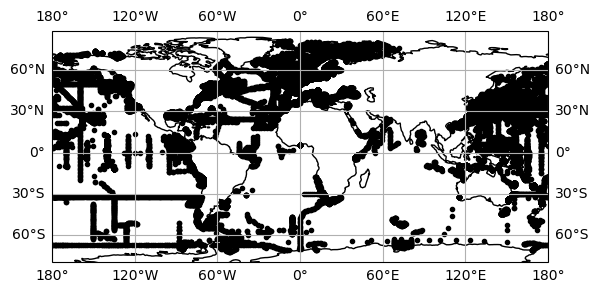

In [35]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

plt.plot(MITprof_ds['prof_lon'], MITprof_ds['prof_lat'], 'k.', transform=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
plt.show()

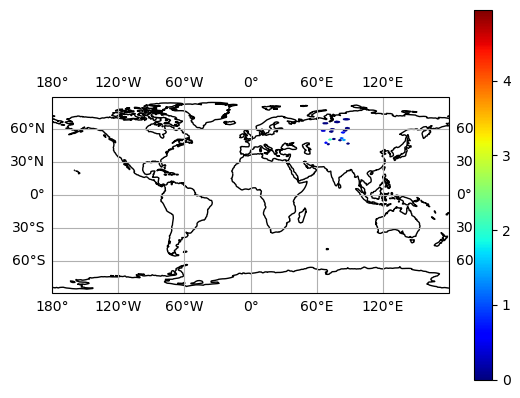

In [36]:
# -------------------------------------------
# Something seems very wrong - tons of bins are on land
# -------------------------------------------


import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as colors

from matplotlib.collections import PatchCollection



key_variable = "T"
key_depth = "00"
key_anomaly_var = "std"

xmin,ymin = 1000, 1000
xmax,ymax = -1000, -1000

value_min = 1000
value_max = -1000

for index in geodesic_bin_data[key_variable][key_depth].keys():
    gbd_polygon = geodesic_bin_data[key_variable][key_depth][index]["artificial_grid_bounding_polygon_for_geodesic_bin"]
    gbd_anomaly_var = geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var]
    if gbd_polygon.size > 0:
       
        if value_min > gbd_anomaly_var:
            value_min = gbd_anomaly_var
            
        if value_max < gbd_anomaly_var:
            value_max = gbd_anomaly_var

norm = colors.Normalize(vmin=value_min, vmax=value_max)
cmap = plt.colormaps.get_cmap('jet')
#cmap = cm.get_cmap('viridis')


# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.coastlines()

value_list = []
patch_list = []

for index in geodesic_bin_data[key_variable][key_depth].keys():
    gbd_polygon = geodesic_bin_data[key_variable][key_depth][index]["artificial_grid_bounding_polygon_for_geodesic_bin"]
    #color_val = cmap(norm(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var]))
    val = norm(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var])
    value_list.append(geodesic_bin_data[key_variable][key_depth][index][key_anomaly_var])
    if gbd_polygon.size > 0:

        
        if xmin > np.min(gbd_polygon[:,0]):
            xmin = np.min(gbd_polygon[:,0])

        if xmax < np.max(gbd_polygon[:,0]):
            xmax = np.max(gbd_polygon[:,0])

        if ymin > np.min(gbd_polygon[:,1]):
            ymin = np.min(gbd_polygon[:,1])

        if ymax < np.max(gbd_polygon[:,1]):
            ymax = np.max(gbd_polygon[:,1])

#        if (np.mean(gbd_polygon[:,0]) < -65 and 
#            np.mean(gbd_polygon[:,0]) > -90 and 
        if (np.mean(gbd_polygon[:,0]) < 90 and 
            np.mean(gbd_polygon[:,0]) > 65 and             
            np.mean(gbd_polygon[:,1]) > 45 and
            np.mean(gbd_polygon[:,1]) < 70):
            patch_list.append(patches.Polygon(gbd_polygon, closed=True))
            value_list.append(val)

        #break

col = PatchCollection(patch_list, cmap=cmap, transform=ccrs.PlateCarree())
col.set_array(value_list) 

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)

ax.add_collection(col)
plt.colorbar(col, ax=ax)  
ax.gridlines(draw_labels=True)
plt.show()

